## Method Delta vs NL2P-1

This section uses the current top-level result directories rather than the older
`results/experiment/` runs. Each delta is computed within the same
`model + dataset` pair:

`delta = strategy F1 - nl2p_1 F1`

Positive bars mean the strategy improved over the original NL2P-1 prompt.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from eval.read_eval import (
    DOMAIN_LABELS,
    DOMAIN_ORDER,
    METHOD_LABELS,
    METHOD_ORDER,
    MODEL_LABELS,
    MODEL_ORDER,
    read_eval_results,
)
from utils.helpers import find_project_root


ROOT = find_project_root()
RESULT_ROOT = ROOT / "results"

result_df = read_eval_results(
    RESULT_ROOT,
    domain_labels=DOMAIN_LABELS,
    method_labels=METHOD_LABELS,
    model_order=MODEL_ORDER,
)


In [3]:
BASE_METHOD = "nl2p_1"
COMPARE_METHODS = [method for method in METHOD_ORDER if method != BASE_METHOD]

baseline_df = result_df[result_df["method"].astype(str) == BASE_METHOD][
    ["domain", "model", "Action F1", "Argument F1"]
].rename(
    columns={
        "Action F1": "Action F1 baseline",
        "Argument F1": "Argument F1 baseline",
    }
)

method_delta_df = result_df[result_df["method"].astype(str).isin(COMPARE_METHODS)].merge(
    baseline_df,
    on=["domain", "model"],
    how="inner",
)
method_delta_df["Action F1 delta"] = method_delta_df["Action F1"] - method_delta_df["Action F1 baseline"]
method_delta_df["Argument F1 delta"] = method_delta_df["Argument F1"] - method_delta_df["Argument F1 baseline"]

display(method_delta_df.head(5))


,domain,method,model,Action Precision,Action Recall,Action F1,Argument Precision,Argument Recall,Argument F1,Adjusted Argument Precision,Adjusted Argument Recall,Adjusted Argument F1,perfect_action_argument_matches,argument_mismatch_actions,matched_action_events,Action F1 baseline,Argument F1 baseline,Action F1 delta,Argument F1 delta
0,win2k,nl2p_1_ablation,gemma3-12b,0.951797,0.870703,0.909446,0.845833,0.579669,0.687902,0.860169,0.888792,0.874246,557,608,1165,0.907233,0.681289,0.002213,0.006614
1,win2k,nl2p_1_coref,gemma3-12b,0.962437,0.862378,0.909665,0.857021,0.580069,0.691858,0.862896,0.890363,0.876414,551,602,1153,0.907233,0.681289,0.002432,0.010570
2,win2k,nl2p_1_ablation,gemma3-27b,0.968569,0.874533,0.919152,0.878481,0.588136,0.704569,0.908377,0.910761,0.909567,556,615,1171,0.900040,0.683844,0.019113,0.020725
3,win2k,nl2p_1_coref,gemma3-27b,0.954774,0.853933,0.901542,0.864035,0.567723,0.685217,0.868607,0.874002,0.871296,536,604,1140,0.900040,0.683844,0.001503,0.001373
4,win2k,nl2p_1_ablation,llama3-70b,0.967156,0.840090,0.899156,0.825112,0.542773,0.654804,0.842491,0.817778,0.829950,499,620,1119,0.908874,0.691110,-0.009718,-0.036306


/tmp/ipykernel_54572/224870872.py:72: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0, 0), 1, 1, color=method_colors[method_key], label=METHOD_LABELS[method_key], edgecolor="white", linewidth=0.5)


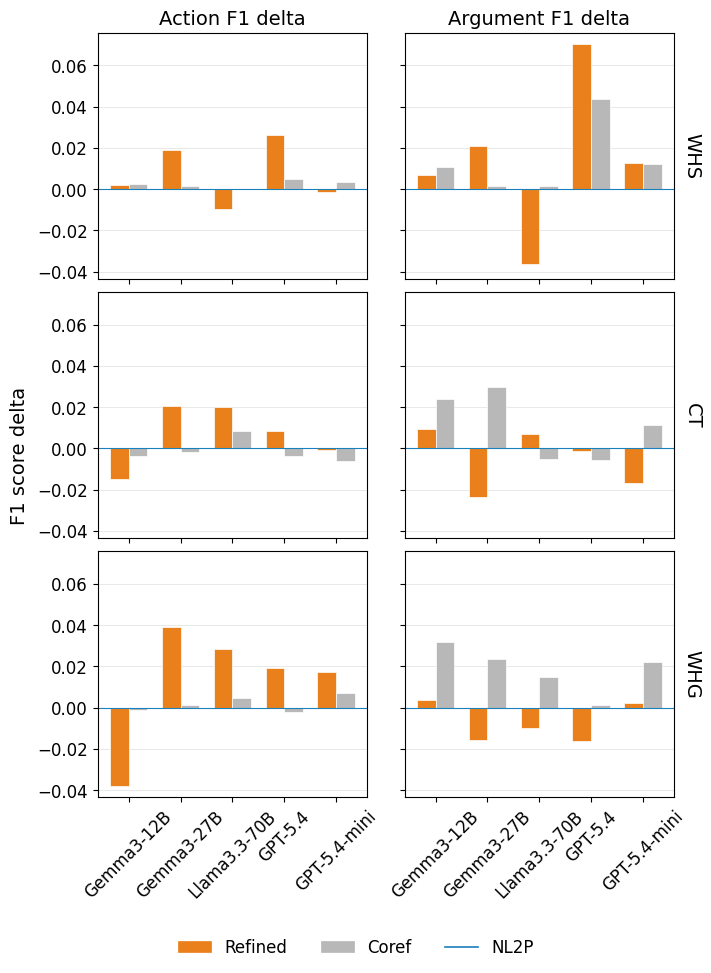

In [ ]:
method_colors = {
    "nl2p_1_ablation": "#ea801c",
    "nl2p_1_coref": "#b8b8b8",
}
offsets = np.linspace(-0.18, 0.18, len(COMPARE_METHODS))
metrics = ["Action F1 delta", "Argument F1 delta"]
models = [model for model in MODEL_ORDER if model in set(method_delta_df["model"].astype(str))]
model_labels = [MODEL_LABELS.get(model, model) for model in models]

# --- Font Size Configuration ---
TITLE_SIZE = 14
LABEL_SIZE = 14
TICK_LABEL_SIZE = 12
LEGEND_SIZE = 12

fig, axes = plt.subplots(
    nrows=len(DOMAIN_ORDER),
    ncols=len(metrics),
    figsize=(7.0, 9.0),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

fig.supylabel("F1 score delta", fontsize=LABEL_SIZE)

x = np.arange(len(models))
width = 0.36

for row_idx, domain in enumerate(DOMAIN_ORDER):
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        panel = method_delta_df[method_delta_df["domain"].astype(str) == domain]

        for method_key, offset in zip(COMPARE_METHODS, offsets):
            values = []
            for model in models:
                row = panel[
                    (panel["method"].astype(str) == method_key)
                    & (panel["model"].astype(str) == model)
                ]
                values.append(np.nan if row.empty else float(row.iloc[0][metric]))

            ax.bar(
                x + offset,
                values,
                width=width,
                color=method_colors[method_key],
                label=METHOD_LABELS[method_key],
                edgecolor="white",
                linewidth=0.5
            )

        ax.axhline(0.0, color="black", linewidth=0.8)
        
        if row_idx == 0:
            ax.set_title(metric, fontsize=TITLE_SIZE)
            
        if col_idx == len(metrics) - 1:
            ax.set_ylabel(DOMAIN_LABELS[domain], rotation=-90, labelpad=20, fontsize=TITLE_SIZE)
            ax.yaxis.set_label_position("right")

        ax.set_xticks(x)
        if row_idx == len(DOMAIN_ORDER) - 1:
            ax.set_xticklabels(model_labels, rotation=45, fontsize=TICK_LABEL_SIZE)
            
        ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
        ax.grid(axis="y", color="#d9d9d9", linewidth=0.6, alpha=0.7)
        ax.set_axisbelow(True)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=method_colors[method_key], label=METHOD_LABELS[method_key], edgecolor="white", linewidth=0.5)
    for method_key in COMPARE_METHODS
]
fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=len(COMPARE_METHODS),
    frameon=False,
    fontsize=LEGEND_SIZE,
)
plt.show()
